## Задание
Продолжаем работать с объединенным датасетом merged_data

**Задача 1** 

Цель: выделить пользователей, которые делают упор на индивидуальные тренировки.

Что сделать:
Выберите пользователей, у которых >70% тренировок — индивидуальные.
Для этих пользователей:
+ Посчитайте средний чек;
+ Посчитайте среднее число тренировок в месяц;
+ Разбейте их по городам и полу.

Вопросы для анализа:

+ Кто чаще выбирает индивидуальные тренировки?
+ Есть ли зависимость от пола или города?
+ Насколько высок средний чек у таких пользователей?

**Задача 2.**
Найдите 10 пользователей с наибольшим общим количеством посещений (групповые + индивидуальные тренировки) за весь период наблюдения.

Что нужно сделать:

+ Рассчитайте общее количество тренировок для каждого пользователя.

+ Определите 10 самых активных пользователей и сохраните их идентификаторы в виде списка.

Постройте распределение этих пользователей по:

+ городу
+ полу

Вопросы для анализа:
+ В каких городах больше всего супер-активных клиентов?
+ Какого они пола?

**Задача 3** 
Ваша цель — проанализировать, как менялась клиентская база по месяцам:
сколько клиентов приходило, сколько уходило и сколько оставалось активными.

Шаги:
+ Новые клиенты — это те, у кого первый месяц появления (минимальный mon в данных).

+ Ушедшие клиенты — это те, у кого последний месяц активности (максимальный mon в данных).

+ Активные клиенты — это те, кто был активен в конкретном месяце.

Что нужно сделать:
Рассчитайте три метрики для каждого месяца:
+ new_clients: количество клиентов, для которых этот месяц — первый.
+ gone_clients: количество клиентов, для которых этот месяц — последний.
+ active_clients: общее количество уникальных клиентов в этом месяце.

Для этого:
Создайте три отдельных датафрейма:

+ с новыми клиентами по месяцам,
+ с ушедшими клиентами по месяцам,
+ с активными клиентами по месяцам.

Объедините их по полю mon.

Постройте линейный график с тремя линиями.

Подсказка:
+ Используйте groupby и nunique() для подсчёта количества клиентов.
+ Для объединения датафреймов — merge.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# загружаем очищенный датасет
df = pd.read_csv('merged_data.csv')
df.head(3)

,id_user,mon,cnt_group,cnt_indiv,sum_group,sum_indiv,cnt_total,sum_total,min_mon,max_mon,city,age,gender
0,1000,2023-03,0,2,0,3600,2,3600,2023-03,2023-12,СПб,44.0,female
1,1000,2023-04,0,4,0,7200,4,7200,2023-03,2023-12,СПб,44.0,female
2,1000,2023-05,0,4,0,6400,4,6400,2023-03,2023-12,СПб,44.0,female


### Задача 1. Пользователи с 70%+ инд.тренировок

In [92]:
user_data = df.groupby(['id_user', 'min_mon', 'city', 'age', 'gender']).\
                       agg({'mon':'count','cnt_group':'sum', 'cnt_indiv':'sum', 'cnt_total':'sum',\
                            'sum_group':'sum', 'sum_indiv':'sum', 'sum_total':'sum'}).reset_index().rename (columns = {'mon': 'nummon'})
user_data.head(5)

,id_user,min_mon,city,age,gender,nummon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total
0,1000,2023-03,СПб,44.0,female,9,0,33,33,0,58600,58600
1,1001,2023-01,Москва,35.0,female,11,106,23,129,84800,40000,124800
2,1002,2023-02,Москва,34.0,male,11,64,64,128,52800,113200,166000
3,1004,2023-02,Екатеринбург,60.0,male,9,0,18,18,0,32000,32000
4,1005,2023-07,СПб,35.0,female,2,0,7,7,0,12600,12600


In [94]:
user_data['sh_indiv'] = user_data['cnt_indiv'] / user_data['cnt_total']
user_data.head(3)

,id_user,min_mon,city,age,gender,nummon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total,sh_indiv
0,1000,2023-03,СПб,44.0,female,9,0,33,33,0,58600,58600,1.000000
1,1001,2023-01,Москва,35.0,female,11,106,23,129,84800,40000,124800,0.178295
2,1002,2023-02,Москва,34.0,male,11,64,64,128,52800,113200,166000,0.500000


In [96]:
user_indiv70 = user_data.loc[user_data['sh_indiv'] >= 0.7].copy()
user_indiv70.head()

,id_user,min_mon,city,age,gender,nummon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total,sh_indiv
0,1000,2023-03,СПб,44.0,female,9,0,33,33,0,58600,58600,1.0
3,1004,2023-02,Екатеринбург,60.0,male,9,0,18,18,0,32000,32000,1.0
4,1005,2023-07,СПб,35.0,female,2,0,7,7,0,12600,12600,1.0
6,1007,2023-01,Москва,58.0,female,4,0,5,5,0,9000,9000,1.0
8,1009,2023-06,Москва,22.0,female,4,0,9,9,0,16200,16200,1.0


In [98]:
user_indiv70['avg_ch'] = user_indiv70['sum_total'] / user_indiv70['nummon']
user_indiv70['avg_tr'] = user_indiv70['cnt_total'] / user_indiv70['nummon']
user_indiv70.head()

,id_user,min_mon,city,age,gender,nummon,cnt_group,cnt_indiv,cnt_total,sum_group,sum_indiv,sum_total,sh_indiv,avg_ch,avg_tr
0,1000,2023-03,СПб,44.0,female,9,0,33,33,0,58600,58600,1.0,6511.111111,3.666667
3,1004,2023-02,Екатеринбург,60.0,male,9,0,18,18,0,32000,32000,1.0,3555.555556,2.000000
4,1005,2023-07,СПб,35.0,female,2,0,7,7,0,12600,12600,1.0,6300.000000,3.500000
6,1007,2023-01,Москва,58.0,female,4,0,5,5,0,9000,9000,1.0,2250.000000,1.250000
8,1009,2023-06,Москва,22.0,female,4,0,9,9,0,16200,16200,1.0,4050.000000,2.250000


In [100]:
user_indiv70['gender'].value_counts()
## Приоритет индивидуальных тренировок чаще у женщин

gender
female    170
male      111
Name: count, dtype: int64

In [102]:
user_indiv70['city'].value_counts()
## По популярности индивидуальных тренировок лидирует с большим отрывом Москва

city
Москва          177
СПб              60
Екатеринбург     24
Казань           20
Name: count, dtype: int64

In [104]:
user_indiv70['avg_ch'].describe()

count      281.000000
mean      5865.579794
std       2662.744725
min       1750.000000
25%       3600.000000
50%       5400.000000
75%       7200.000000
max      14800.000000
Name: avg_ch, dtype: float64

In [106]:
user_data['avg_check_per_mon'] = user_data['sum_total'] / user_data['nummon']
user_data['avg_check_per_mon'].describe()

count      838.000000
mean      7026.329378
std       3536.038533
min       1540.000000
25%       4400.000000
50%       6340.000000
75%       9000.000000
max      19900.000000
Name: avg_check_per_mon, dtype: float64

In [108]:
avg_check_all = user_data
avg_check_ind70 = user_indiv70['avg_ch'].mean()
avg_check_ind70
## Средний чек по пользователям, предпочитающим индивидуальные тренировки: 
## он невысокий, учитывая, что средний чек по всем пользователям - около 7000 руб.
## Кроме того, средний чек по пользователям, предпочитающим индивидуальные тренировки
## отстает от среднего чека по всем пользователям и по моде

5865.579793871609

In [110]:
city_indiv = user_indiv70.groupby('city').agg({'id_user' : 'nunique', 'avg_ch' : 'mean', 'avg_tr' : 'mean', 'sh_indiv' : 'mean'})\
.reset_index().rename (columns = {'id_user' : 'nusers'})
city_indiv

,city,nusers,avg_ch,avg_tr,sh_indiv
0,Екатеринбург,24,5612.070106,3.132854,1.000000
1,Казань,20,5656.626984,3.261429,0.985897
2,Москва,177,6015.389121,3.385118,0.998588
3,СПб,60,5594.697090,3.129888,1.000000


In [112]:
pivot_city_gen = pd.pivot_table (user_indiv70, index = 'city', columns = 'gender', values = 'id_user', aggfunc = 'count')
pivot_city_gen

gender,female,male
city,,
Екатеринбург,12,12
Казань,8,12
Москва,118,59
СПб,32,28


In [ ]:
### Задача 2. Топ-10 клиентов

In [114]:
list_top10 = df.groupby('id_user').agg(cnt_tr = ('cnt_total', 'sum')).reset_index().sort_values('cnt_tr', ascending = False).head(10)['id_user'].tolist()
list_top10

[1381, 1013, 1657, 1506, 1929, 1001, 1570, 1002, 1582, 1194]

In [118]:
user_top10 = df[df['id_user'].isin (list_top10)].groupby(['id_user', 'city', 'gender', 'age']).\
agg({'mon' : 'count', 'cnt_total' : 'sum', 'sum_total' : 'sum'}).reset_index()\
.rename(columns = {'mon' : 'months'})
user_top10

,id_user,city,gender,age,months,cnt_total,sum_total
0,1001,Москва,female,35.0,11,129,124800
1,1002,Москва,male,34.0,11,128,166000
2,1013,Москва,male,43.0,11,151,139800
3,1194,СПб,female,27.0,12,127,114600
4,1381,Москва,female,25.0,12,159,147600
5,1506,Москва,female,29.0,10,138,146400
6,1570,Екатеринбург,male,39.0,11,129,103200
7,1582,Екатеринбург,male,37.0,8,127,136200
8,1657,СПб,male,27.0,10,144,164200
9,1929,Москва,male,32.0,11,130,116600


In [120]:
pivot_city_gen_top10 = pd.pivot_table (user_top10, index = 'city', columns = 'gender', values = 'id_user', aggfunc = 'count')
pivot_city_gen_top10
## В основном суперактивные пользователи проживают в Москве, при этом среди самых активных пользователей больше мужчин

gender,female,male
city,,
Екатеринбург,NaN,2.0
Москва,3.0,3.0
СПб,1.0,1.0


### Задача 3. Динамика клиентской базы

In [63]:
df['mon'] = pd.to_datetime(df['mon'], format = "%Y-%m")
df['min_mon'] = pd.to_datetime(df['min_mon'], format = "%Y-%m")
df['max_mon'] = pd.to_datetime(df['max_mon'], format = "%Y-%m")

In [65]:
new_users=df[df['mon'] == df ['min_mon']].groupby('mon')['id_user'].nunique().reset_index()
new_users

,mon,id_user
0,2023-01-01,337
1,2023-02-01,88
2,2023-03-01,83
3,2023-04-01,62
4,2023-05-01,57
5,2023-06-01,51
6,2023-07-01,48
7,2023-08-01,35
8,2023-09-01,28
9,2023-10-01,27


In [67]:
active_users=df.groupby('mon')['id_user'].nunique().reset_index()
active_users

,mon,id_user
0,2023-01-01,337
1,2023-02-01,350
2,2023-03-01,355
3,2023-04-01,345
4,2023-05-01,360
5,2023-06-01,383
6,2023-07-01,412
7,2023-08-01,423
8,2023-09-01,429
9,2023-10-01,441


In [69]:
gone_users=df[df['mon'] == df ['max_mon']].groupby('mon')['id_user'].nunique().reset_index()
gone_users

,mon,id_user
0,2023-01-01,15
1,2023-02-01,22
2,2023-03-01,37
3,2023-04-01,21
4,2023-05-01,21
5,2023-06-01,13
6,2023-07-01,33
7,2023-08-01,33
8,2023-09-01,55
9,2023-10-01,101


In [71]:
n_g_users = new_users.merge(gone_users, on = 'mon').rename(columns = {'id_user_x' : 'cnt_new_users', 'id_user_y' : 'cnt_gone_users'})
all_users = n_g_users.merge(active_users, on = 'mon').rename(columns = {'id_user' : 'cnt_act_users'})
all_users

,mon,cnt_new_users,cnt_gone_users,cnt_act_users
0,2023-01-01,337,15,337
1,2023-02-01,88,22,350
2,2023-03-01,83,37,355
3,2023-04-01,62,21,345
4,2023-05-01,57,21,360
5,2023-06-01,51,13,383
6,2023-07-01,48,33,412
7,2023-08-01,35,33,423
8,2023-09-01,28,55,429
9,2023-10-01,27,101,441


In [73]:
all_users['mon'] = all_users['mon'].dt.strftime ("%Y-%m")

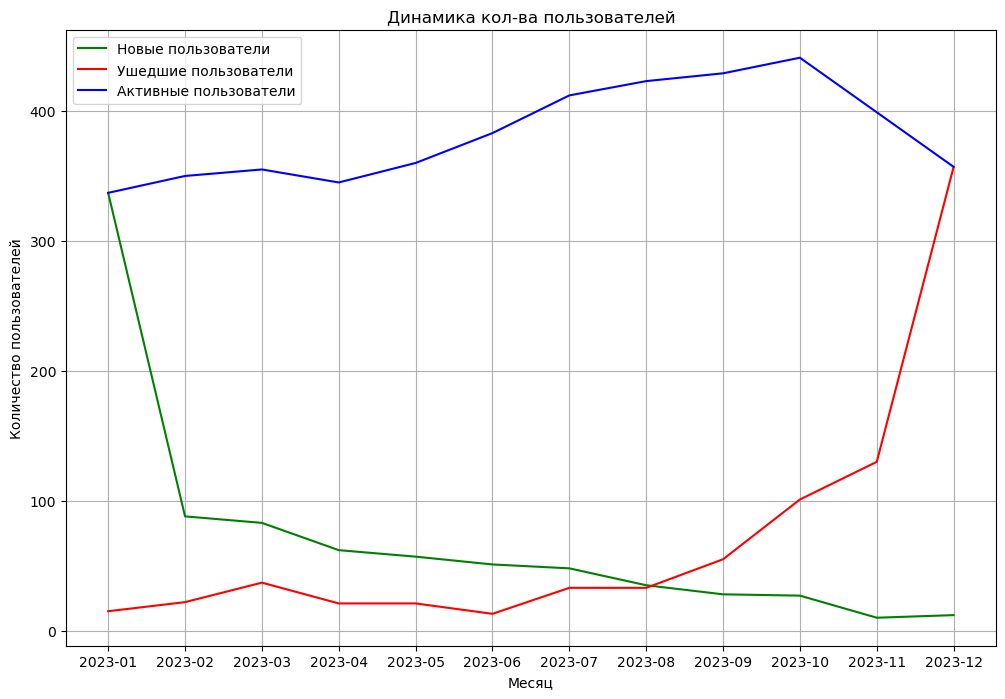

In [75]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 8))
ax.plot(all_users['mon'], all_users['cnt_new_users'], 'g', label = 'Новые пользователи')
ax.plot(all_users['mon'], all_users['cnt_gone_users'], 'r', label = 'Ушедшие пользователи')
ax.plot(all_users['mon'], all_users['cnt_act_users'], 'b', label = 'Активные пользователи')
plt.xlabel('Месяц')
plt.ylabel('Количество пользователей')
plt.title('Динамика кол-ва пользователей')
plt.legend()
plt.grid(True)
plt.show()